# Train and fit SRV

# Overview
1. Use `TrajectoryDataset`, `VAMPNet`, `SRV` 
2. Use `WeightedTrajectoryDataset`, `WeightedVAMPNet`, `WeightedSRV`

### For each
1. Load dataset
2. Train VAMPnet
3. Fit SRV

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch

from src.param import SimulationParameters
from src.data import simulation_data
from src.plots import plot_dihedrals_hist2d

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using CUDA, Torch version {torch.__version__}')
    print('-------------------------------------')
else:
    device = torch.device('cpu')
dtype = torch.float32

/home/bharland/anaconda3/envs/openmm-torch/lib/python3.13/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA driver initialization failed, you might not have a CUDA gpu. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1751416275554/work/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA version (PyTorch):", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("No CUDA device available")

PyTorch version: 2.7.1
CUDA version (PyTorch): 12.9
CUDA available: False
CUDA device count: 1
No CUDA device available


# A. `TrajectoryDataset`, `VAMPNet`, `SRV`

## A.1 Load unbiased dataset

Loaded SimulationData object from data/unbiased with 350000 frames
len(dataset) = 349999


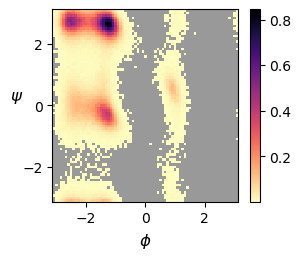

In [4]:
from src.dataset import TrajectoryDataset

p = SimulationParameters('data/unbiased')
sd = simulation_data(p, assign_labels=['dihedrals', 'features'])
dataset = TrajectoryDataset(sd.features)
print(f'{len(dataset) = }')

fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))
plot_dihedrals_hist2d(fig, ax, sd.dihedrals)

## A.2 Train VAMPnet

device = device(type='cuda'), torch.backends.cudnn.enabled = True
torch.cuda.is_available() = True, torch.__version__ = '2.1.2.post301'


VAMPnet epoch:   0%|          | 0/5 [00:00<?, ?it/s]

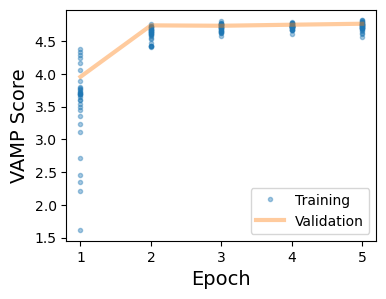

In [6]:
from src.dataset import data_loaders
from src.vampnet import vampnet
from tqdm.notebook import tqdm

calculate = True
if calculate:
    num_epochs = 5
    vn = vampnet(p, weighted=False)
    vn.fit(*data_loaders(dataset, p.frac_test), num_epochs=num_epochs, progress=tqdm)
    sd.save_and_assign_objects({'vampnet': vn})
else:
    sd.assign_objects(['vampnet'])

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(*sd.vampnet.train_scores.T, '.', alpha=0.4, label='Training')
ax.plot(*sd.vampnet.test_scores.T, '-', linewidth=3, alpha=0.4, label='Validation')
ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('VAMP Score', fontsize=14)
ax.legend()

## A.3 Fit SRV

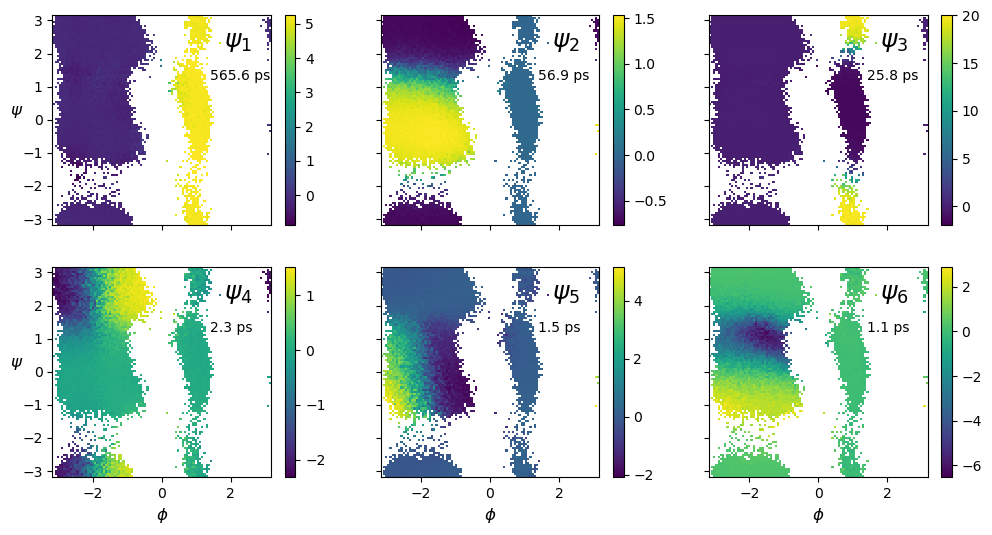

In [7]:
from src.vampnet import SRV
from src.plots import plot_eigfuncs

calculate = True
if calculate:
    srv = SRV(sd.vampnet.net, p.lagtime._value)
    srv.fit(dataset)
    sd.save_eigen_data(srv)
else:
    sd.assign_objects(['srv'])

fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
plot_eigfuncs(fig, axs, sd.theta_grid, sd.psi_grid, sd.timescales)

# B. `WeightedTrajectoryDataset`, `WeightedVAMPNet`, `WeightedSRV`

### B.1 Load data as weighted dataset (weights = $[1, 1, \ldots, 1]$)

len(dataset) = 349999


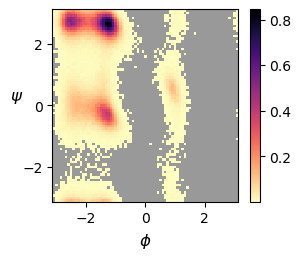

In [ ]:
from src.dataset import WeightedTrajectoryDataset

if not sd.files['weights'].exists():
    sd.save_and_assign_objects({'weights': np.ones(len(sd.features))})
else:
    sd.assign_objects(['weights'])

dataset = WeightedTrajectoryDataset(sd.features, sd.weights)
print(f'{len(dataset) = }')

fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))
plot_dihedrals_hist2d(fig, ax, sd.dihedrals)

## B.2 Train VAMPnet (overwrites data from unweighted VAMPnet)

device = device(type='cuda'), torch.backends.cudnn.enabled = True
torch.cuda.is_available() = True, torch.__version__ = '2.1.2.post301'


VAMPnet epoch:   0%|          | 0/10 [00:00<?, ?it/s]

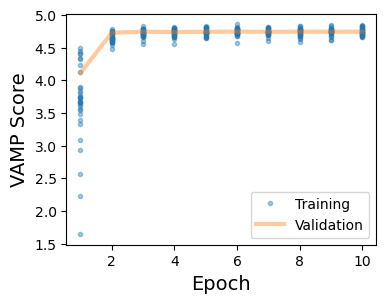

In [22]:
calculate = True
if calculate:
    num_epochs = 10
    vn = vampnet(p, weighted=True)
    vn.fit(*data_loaders(dataset, p.frac_test), num_epochs=num_epochs, progress=tqdm)
    sd.save_and_assign_objects({'vampnet': vn})
else:
    sd.assign_objects(['vampnet'])

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(*sd.vampnet.train_scores.T, '.', alpha=0.4, label='Training')
ax.plot(*sd.vampnet.test_scores.T, '-', linewidth=3, alpha=0.4, label='Validation')
# ax.set_xticks(list(range(1, num_epochs + 1)))
ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('VAMP Score', fontsize=14)
ax.legend()

## B.3 Fit SRV

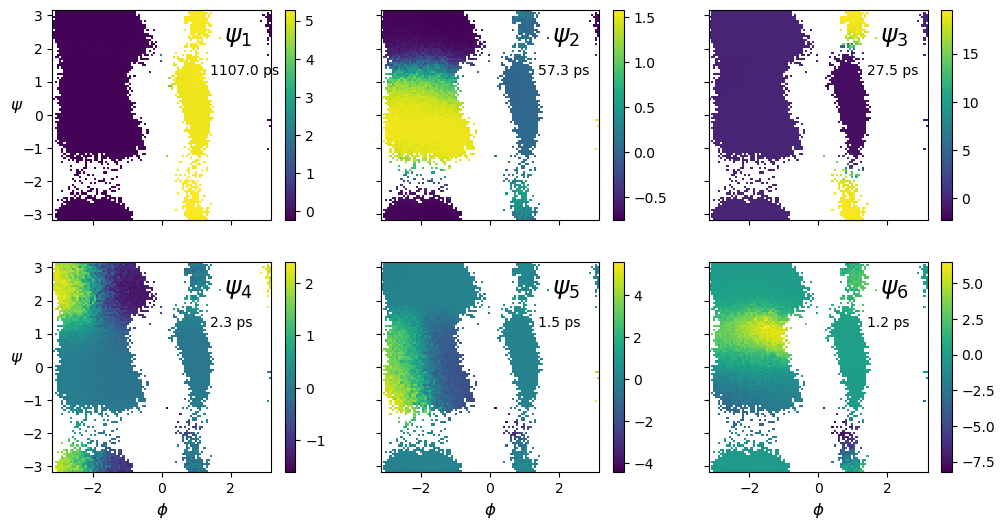

In [23]:
from src.vampnet import WeightedSRV

calculate = True
if calculate:
    srv = WeightedSRV(sd.vampnet.net, p.lagtime._value)
    srv.fit(dataset)
    sd.save_eigen_data(srv)
else:
    sd.assign_objects(['srv'])

fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
plot_eigfuncs(fig, axs, sd.theta_grid, sd.psi_grid, sd.timescales)